# Comparacion de los Modelos de regresion lineal simple, Rigde, Lasso y Elastic Net 

## Limpieza de datos
Para este caso se comenzara por leer el archivo de los datos para hacer un analisis rapido. 



In [ ]:
import pandas as pd

df = pd.read_csv(r"D:\TODO\Python\files\Dataset\global_climate_energy_2020_2024.csv")
df.head()


In [ ]:
df.dtypes

In [ ]:
#Verificacion que no tenga valores iguales a 0 o vacios
df.isnull().sum()

In [ ]:
#Tamaño del dataframe
df.shape

In [ ]:
#Cambio de los nombres de las columnas 
df = df.copy()
new_names =  [
    "Fecha",
    "Pais",
    "Temperatura_promedio_C°",
    "Humedad_%",
    "Emisiones_CO2",
    "Consumo_energia_MWh",
    "Porcentaje_de_Energia_renovable_%",
    "Poblacion_urbana",
    "Indic_de_actividad_industrial",
    "Precio_energia_electrica_€/MWh"
    ]
if len(new_names) != len(df.columns):
    raise ValueError("la cantidad de nombres no coincide con los de la columna")

df.columns = new_names
df.head()


In [ ]:
#Cambio de tipo de datos de fecha a datetime64
df["Fecha"] = pd.to_datetime(df["Fecha"],errors="coerce")
df.dtypes

In [ ]:
#correlacion entre las variables
df.corr(numeric_only=True)

## Regresion lineal multiple simple 

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    max_error,
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

x = df[["Temperatura_promedio_C°",
    "Humedad_%",
    "Consumo_energia_MWh",
    "Porcentaje_de_Energia_renovable_%",
    "Poblacion_urbana",
    "Indic_de_actividad_industrial",
    "Precio_energia_electrica_€/MWh"]]
y = df["Emisiones_CO2"]

x_train,x_test,y_train,y_test = train_test_split(x,
                                                 y,
                                                 test_size=0.2,
                                                 random_state=45)
pipeline_linear_regression = Pipeline([("scaler_regression",StandardScaler()),
                                      ("linear_regression",LinearRegression(n_jobs=-1))]
                                      
                                    )
#validacion cruzada de los datos para verificar la veracidad de los datos con multiples bloques de entrenamiento.
#La metrica que se verificara es el menor error promedio cuadratico
validacion_cruzada = cross_val_score(pipeline_linear_regression,
                        x,
                        y,
                        cv=5,
                        scoring="neg_root_mean_squared_error")

pipeline_linear_regression.fit(x_train,y_train)
prediccion = pipeline_linear_regression.predict(x_test)
mae_lr = (mean_absolute_error(y_test,prediccion))
rmse_lr= root_mean_squared_error(y_test,prediccion)
max_error_lr = max_error(y_test,prediccion)
r2_lr = r2_score(y_test,prediccion)
cantidad_variables_linear_regression = len(x.columns)
print("="*20+"MODELO DE REGRESION LINEAR REGRESSION"+"="*20)
print("*"*100)
print("="*20+"Variable de determanacion para el modelo linear_regression"+"="*20)
print(f"R2 es igual a :{r2_lr:.4f}")
print("="*100)
print(f"Maximo error absoluto en el modelo es : {max_error_lr:.4f}")
print("="*100)
print (f"Raiz del error pormedio cuadratico es igual a : {rmse_lr:.4f}")
print(f"validacion cruzada:{-validacion_cruzada.mean()}")
print("="*100)
print(f"promedio del error absoluto : {mae_lr:.4f}")
print("="*100)
print(f"Cantidad de variables en el modelo : {cantidad_variables_linear_regression}")









## Regression Ridge
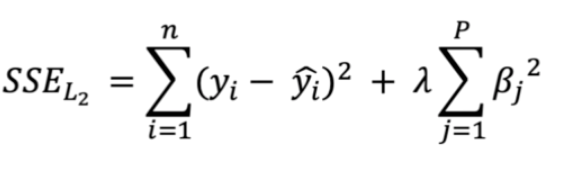

*Esta regresion de cresta nos ayudara a penalizar los coeficientes para mejorar la varianza , pero afectando un Bias del modelo*

In [ ]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures

#Rango de hiperametro alpha para la penalizacion de los coeficientes al cuadrado (l2)
alphas = np.logspace(-4,4,20)
grados = np.arange(1,4)
pipeline_ridge = Pipeline([
    ("plyo_ridge",PolynomialFeatures(include_bias=False)), #Genera nuevas caracteristicas con grado polinomico optimizado por el GridSearchCV, y se crearan nuevas varibles con las originales
    ("stander_ridge",StandardScaler()),
    ("ridge",Ridge(random_state=45))
])
parametros_ridge = {
    "plyo_ridge__degree":grados,
    "ridge__alpha":alphas,  
}
#Usamos el metodo GridsearchCV para encontrar el mejor parametro de alpha , asi encontramos el menor error cuadratico, mejorando el modelo 
grid_ridge = GridSearchCV(
    pipeline_ridge,
    parametros_ridge,
    cv=5,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error",
    verbose=3
)
grid_ridge.fit(x_train,y_train)
best_model_ridge = grid_ridge.best_estimator_
variables_ridge = len(best_model_ridge.named_steps["plyo_ridge"].get_feature_names_out(x.columns))
prediccion_ridge = best_model_ridge.predict(x_test)
r2_ridge = best_model_ridge.score(x_test,y_test)
max_error_ridge = max_error(y_test,prediccion_ridge)
mae_ridge = mean_absolute_error(y_test,prediccion_ridge)
rmse_ridge = root_mean_squared_error(y_test,prediccion_ridge)
cross_validation_ridge = -grid_ridge.best_score_
best_alpha_ridge = grid_ridge.best_params_["ridge__alpha"]
best_degree_ridge = grid_ridge.best_params_["plyo_ridge__degree"]
print("="*30+ "Regreassion Ridge" +"="*30)
print("="*20 + "Coeficiente de determinacion R2 del modelo Ridge" + "="*20)
print(f"R2 es igual: {r2_ridge:.4f}")
print("="*50)
print(f"Error absoluto medio : {mae_ridge:.4f}")
print("="*50)
print(f"Raiz del error medio cuadratico: {rmse_ridge:.4f}")
print(f"Validacion cruzada : {cross_validation_ridge:.4f}")
print("="*50)
print(f"Maximo error : {max_error_ridge:.4f}")
print("="*50)
print(f"Mejor hiperametro alpha : {best_alpha_ridge:.4f}")
print("="*50)
print(f"Mejor grado polinomico : {best_degree_ridge:.4f}")
print("="*50)
print(f"Cantidad de variables del modelo Rigde: {variables_ridge}")






# Regression Lasso
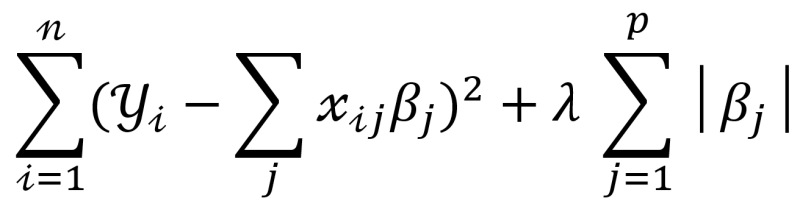

In [ ]:
from sklearn.linear_model import Lasso

pipeline_lasso = Pipeline([
    ("poly_lasso",PolynomialFeatures(degree=3,include_bias=False)),
    ("scaler_lasso",StandardScaler()),
    ("lasso",Lasso(max_iter=50000))
])
parametros_lasso = {"lasso__alpha":alphas}
grid_lasso = GridSearchCV(pipeline_lasso,parametros_lasso,cv=5,n_jobs=-1, scoring="neg_root_mean_squared_error",verbose=1)
grid_lasso.fit(x_train,y_train)
best_model_lasso = grid_lasso.best_estimator_
coeficientes_lasso = best_model_lasso.named_steps["lasso"].coef_
cantidad_var_lasso = np.sum(coeficientes_lasso !=0)
prediccion_lasso = best_model_lasso.predict(x_test)
r2_lasso = r2_score(y_test,prediccion_lasso)
mae_lasso = mean_absolute_error(y_test,prediccion_lasso)
rmse_lasso = root_mean_squared_error(y_test,prediccion_lasso)
validacion_lasso = -grid_lasso.best_score_
best_alpha_lasso = grid_lasso.best_params_["lasso__alpha"]
max_error_lasso = max_error(y_test,prediccion_lasso)
tabla = pd.DataFrame({
    "Variables_lasso":best_model_lasso.named_steps["poly_lasso"].get_feature_names_out(x.columns),
    "Coeficientes":best_model_lasso.named_steps["lasso"].coef_
}) 
tabla_coef = (tabla[tabla["Coeficientes"]!=0].sort_values(by="Coeficientes",ascending=False,key=lambda col: col.abs())).head(10)

print("="*30+ "Regreassion Lasso" +"="*30)
print("="*20 + "Coeficiente de determinacion R2 del modelo Lasso" + "="*20)
print(f"R2 es igual a: {r2_lasso:.4f}")
print("="*50)
print(f"Error absoluto medio: {mae_lasso:.4f}")
print("="*50)
print(f"Raiz del error medio cuadratico: {rmse_lasso:.4f}")
print(f"validacion cruzada: {validacion_lasso:.4f}")
print("="*50)
print(f"Maximo error : {max_error_lasso:4f}")
print("="*50)
print(f"Mejor hiperametro alpha : {best_alpha_lasso:.4f}")
print("="*50)
print(f"Cantidad de variables del modelo lasso : {cantidad_var_lasso} ")
print("="*50)
print("Tabla de los coeficientes")
print(tabla_coef)



In [ ]:
modelos = ["regresion lineal","rigde","lasso"]
R2_general = [r2_lr,r2_ridge,r2_lasso]
RMSE_general =[rmse_lr,rmse_ridge,rmse_lasso]
MAE_general = [mae_lr,mae_ridge,mae_lasso]
alpha_general = ["",best_alpha_ridge,best_alpha_lasso]
Cantidad_variables_general =[cantidad_variables_linear_regression,variables_ridge,cantidad_var_lasso]

tabla_general = pd.DataFrame({
    "modelos":modelos,
    "R2":R2_general,
    "RMSE_general":RMSE_general,
    "MAE_general":MAE_general,
    "alpha":alpha_general,
   "variables":Cantidad_variables_general


})
tabla_general.sort_values(by="R2",ascending=False)


In [ ]:
import matplotlib.pyplot as plt

colores = ["red","blue","green"]
fig, ax = plt.subplots(figsize = (8,4))

ax.barh(
    tabla_general["modelos"],
    tabla_general["R2"],
    color = colores
)
